In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from stericheight.utils import Color as uc
from load_meop import MEOP
pfns = PlottingFns()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import xesmf as xe
import matplotlib.patches as mpatches


ARGO = '/nfs/b0133/eejco/data/ARGO/DataSelection_a0ad0869-68c3-4b7d-af4c-9c010ab6e378/'




In [4]:
#define helper functions
def get_trend(da: xr.DataArray,ns=True):
    ns_2_yr = lambda x: x * 1e9 * 60 * 60 * 24 * 365.25
    p = da.polyfit(dim='time',deg=1)
    m = p.polyfit_coefficients.sel(degree=1)
    m = m.assign_coords(longitude=da.longitude)
    return ns_2_yr(m) if ns else m

def cropds_to_extent(ds: xr.Dataset, extent):
    return ds.where((ds.latitude >= extent[2]) & 
                    (ds.latitude <= extent[3]) &
                    (ds.longitude >= extent[0]) &
                    (ds.longitude <= extent[1]), drop=True)

def cropdf_to_extent(df: pd.DataFrame, extent):
    return df[(df.lat >= extent[2]) & 
              (df.lat <= extent[3]) &
              (df.lon >= extent[0]) &
              (df.lon <= extent[1])]

def season_split(da):
    # divide by season
    months = da.time.dt.month
    seasons = dict()
    seasons['winter'] = da.where((months >=7) & (months <=9))
    seasons['spring'] = da.where((months >=10) & (months <=12))
    seasons['summer'] = da.where((months >=1) & (months <=3))
    seasons['autumn'] = da.where((months >=4) & (months <=6))
    return seasons

def seasonal_anomaly(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()


In [5]:
lwe_ds = GRACE().ds
sla = SLA(deg=1).da
sla0 = SLA(deg=0.25).da
dot_ds = DOT().ds

In [6]:
gpha = GPHA()

In [7]:
elevation_ = GEBCO(coarsen_factor=40).ds.elevation
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')


In [8]:
profiles = gpha.profile_df
profiles_gridded = gpha.gridded_ds

In [9]:
data_extent = [-90,-75,-73,-69]
map_extent = [-90,-75,-73,-69]

In [10]:
profiles = cropdf_to_extent(profiles,data_extent)
profiles_gridded = cropds_to_extent(profiles_gridded,data_extent)

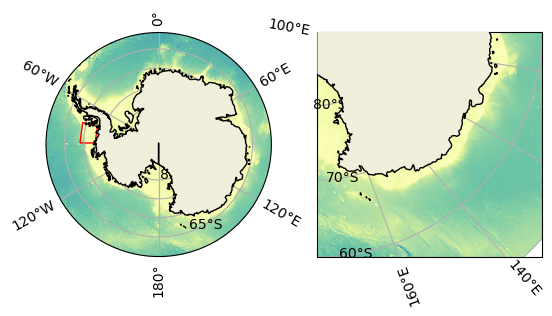

In [11]:
fig, ax = plt.subplots(1,2,subplot_kw={"projection":ccrs.SouthPolarStereo()})
pfns.sp(ax[0],elevation_,sea='Small Southern Ocean')
extent = data_extent
ax[0].add_patch(mpatches.Rectangle(xy=[extent[0], extent[2]],
                                width=extent[1]-extent[0],
                                height=extent[3]-extent[2],
                                facecolor='none', edgecolor='r',
                                transform=ccrs.PlateCarree()))
pfns.sp(ax[1],elevation_,extent=[90,180,-80,-60])
ax[1].add_patch(mpatches.Rectangle(xy=[extent[0], extent[2]],
                                width=extent[1]-extent[0],
                                height=extent[3]-extent[2],
                                facecolor='none', edgecolor='r',
                                transform=ccrs.PlateCarree()))

In [12]:
# crop elevation
elevation = elevation_.sel(latitude = slice(map_extent[2], map_extent[3]), longitude = slice(map_extent[0],map_extent[1]))

In [13]:
sha_ds_sla = StericHeight(ssh_ref='DOT',
                      ssh=sla,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()


sha_ds_dot = StericHeight(ssh_ref='DOT',
                      ssh=dot_ds.dot,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()

In [14]:
sha_ds_sla = cropds_to_extent(sha_ds_sla,data_extent)
sha_ds_dot = cropds_to_extent(sha_ds_dot,data_extent)

In [15]:
profiles_sla = profiles_gridded.interp_like(sla)

In [16]:
sha_gph_sla = xr.merge([sha_ds_sla,profiles_sla])
sha_gph_dot = xr.merge([sha_ds_dot,profiles_gridded])


In [17]:
sha_gph_sla['profile_gpha'] = 100*(sha_gph_sla.profile_gph - sha_gph_sla.profile_gph.sel(time=slice(sla.time[0],sla.time[-1])).mean('time'))
sha_gph_dot['profile_gpha'] = 100*(sha_gph_dot.profile_gph - sha_gph_dot.profile_gph.sel(time=slice(dot_ds.dot.time[0],dot_ds.dot.time[-1])).mean('time'))

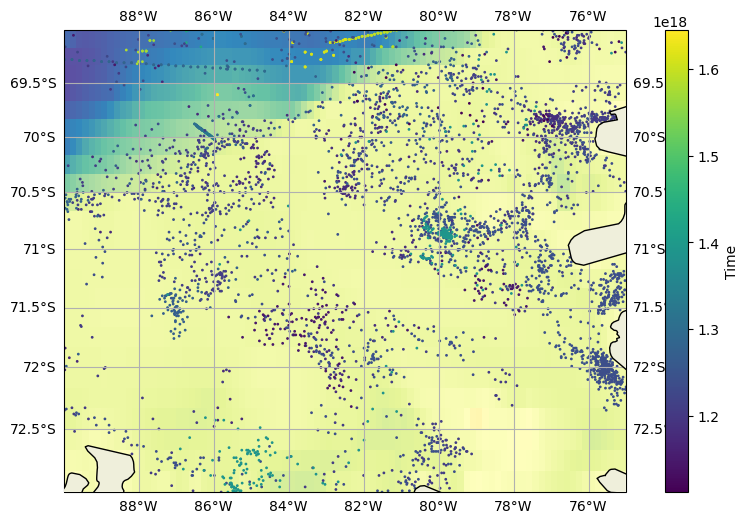

In [18]:
fig, ax = plt.subplots(figsize=(10,6), subplot_kw={'projection':ccrs.Mercator()})
pfns.sp(ax=ax,da=elevation,extent=map_extent)
im=ax.scatter(profiles.lon, profiles.lat, [1 for t in profiles.index], profiles.index, transform=ccrs.PlateCarree())
cbar = plt.colorbar(im, label='Time')


In [37]:
profiles_monthly = profiles[(profiles.index >= sla0.time[0].to_pandas()) & (profiles.index <= sla0.time[-1].to_pandas())].groupby(pd.Grouper(freq='MS'))
profiles_sum = profiles_monthly.count().gph.sum()
monthly_sum = profiles_gridded.profile_cnt.groupby('time.month').sum()
yearly_sum = profiles_gridded.profile_cnt.groupby('time.year').sum()

In [38]:
def timeseries_compare(ds,annual=True,fig=None, ax=None):

        # take annual mean
        data_spatial = ds.groupby('time.year').mean('time',skipna=True) if annual else ds

        # spatial average
        data = data_spatial.mean(['latitude','longitude'])
        
        plot_time = data.year if annual else data.time
        
        # plot sh and gph on different axes
        def plot(ax,var,c,title,marker='x-'):
            ax.plot(plot_time,data[var].to_numpy(),marker,c=c,label=title)
            
        # plot bar to show number of profiles
        if annual:
            plot(ax,'sha',uc.SHA.value[0],'SHA')
            plot(ax,'profile_gpha',uc.GPHA.value[0],'GPH')
            ax.grid()
            ax.legend()
            ax.set_ylabel('Annual height anomaly (cm)')
        else:
            plot(ax,'sha',uc.SHA.value[1],'SHA Monthly',marker='x')
            plot(ax,'profile_gpha',uc.GPHA.value[1],'GPHA Monthly',marker='x')
            data.sha.rolling(time=12,min_periods=2,center=True).mean().plot(ax=ax,label="SHA 12-Month Average",c=uc.SHA.value[0])
            data.profile_gpha.rolling(time=12,min_periods=2,center=True).mean().plot(ax=ax,label="GPHA 12-Month Average",c=uc.GPHA.value[0])
            ax.legend(loc = 'upper right',fontsize='small')
            ax.grid()
            ax.set_ylabel('Monthly SHA/GPHA (cm)')
            ax.set_xlabel(None)
        
        return fig, ax


def timeseries_compare_nongrid(ds,fig=None, ax=None):

        profiles_monthly = profiles.gph.groupby(pd.Grouper(freq='MS')).mean() * 100
        data = ds.mean(['latitude','longitude'])

        ax2 = ax.twinx()
                
        # plot SHA monthly
        ax.plot(ds.time,data['sha'].to_numpy(),'x-',c=uc.SHA.value[1],label='SHA Monthly')
        ax2.plot(profiles_monthly.index,profiles_monthly,'x',c=uc.GPHA.value[1],label='GPHA Monthly')

        # plot rolling means
        data.sha.rolling(time=12,min_periods=2,center=True).mean().plot(ax=ax,label="SHA 12-Month Average",c=uc.SHA.value[0])
        profiles_monthly.to_xarray().rolling(time=12,min_periods=2,center=True).mean().plot(ax=ax2,label="GPHA 12-Month Average",c=uc.GPHA.value[0])

        ax.legend(loc = 'upper right',fontsize='small')
        ax.grid()
        ax.set_ylabel('Monthly SHA/GPH (cm)')
        ax.set_xlabel(None)
        
        return fig, ax

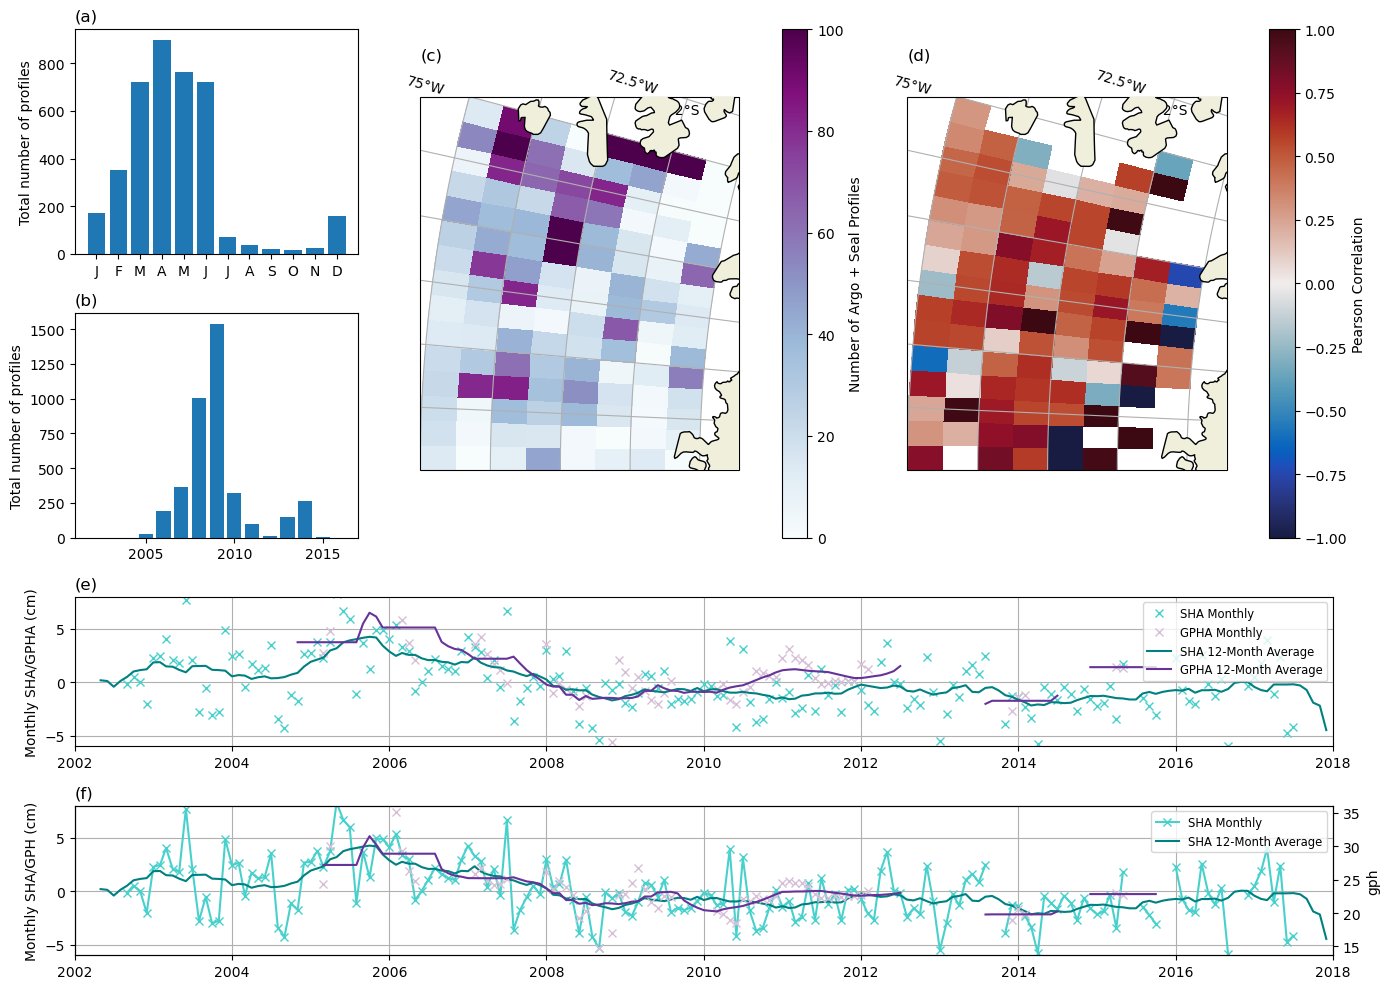

In [39]:
# gpha, sla, gridded
fig = plt.figure(figsize=(14,10))
axs=[]

gs = fig.add_gridspec(4,3,height_ratios=[1.5,1.5,1,1],width_ratios=[1,1.5,1.5])

# sha, gpha and sic climatology
axs.append(fig.add_subplot(gs[0, 0]))
axs.append(fig.add_subplot(gs[1, 0]))

axs[0].bar(monthly_sum.month,monthly_sum.sum(['latitude','longitude']))
axs[0].set_xticks(np.arange(1,13))
axs[0].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
#axs[0].ax.set_xlim([0.5,12.5])
axs[0].set_ylabel('Total number of profiles')
axs[0].set_title('(a)',loc='left')


axs[1].bar(yearly_sum.year,yearly_sum.sum(['latitude','longitude']))
axs[1].set_xlim([2001,2017])
axs[1].set_ylabel('Total number of profiles')
axs[1].set_title('(b)',loc='left')

axs[0].set_title('(a)',loc='left')
axs[1].set_title('(b)',loc='left')

# density and correlation
axs.append(fig.add_subplot(gs[0:2, 1],projection=ccrs.SouthPolarStereo()))
axs.append(fig.add_subplot(gs[0:2, 2],projection=ccrs.SouthPolarStereo()))

pfns.sp(axs[2],sha_gph_dot.profile_cnt.sum(('time')),vmin=0,vmax=100,cbar="Number of Argo + Seal Profiles",cmap='BuPu',cbar_orientation='vertical',extent=data_extent)
axs[2].set_title('(c)',loc='left')

pfns.sp(axs[3],xr.corr(sha_gph_dot.sha,sha_gph_dot.profile_gpha,dim='time'),cmap=cmocean.cm.balance,cbar='Pearson Correlation',cbar_orientation='vertical',extent=data_extent)
axs[3].set_title('(d)',loc='left')

axs.append(fig.add_subplot(gs[2, 0:4]))

timeseries_compare(sha_gph_dot,annual=False,fig=fig,ax=axs[4])
axs[4].set_title('(e)',loc='left')
axs[4].set_ylim([-6,8])
axs[4].set_xlim([pd.Timestamp(2002,1,1),pd.Timestamp(2018,1,1)])

axs.append(fig.add_subplot(gs[3,0:4]))

timeseries_compare_nongrid(sha_gph_dot,fig=fig,ax=axs[5])
axs[5].set_title('(f)',loc='left')
axs[5].set_ylim([-6,8])
axs[5].set_xlim([pd.Timestamp(2002,1,1),pd.Timestamp(2018,1,1)])


plt.tight_layout()



In [32]:
monthly_sum = profiles_sla.profile_cnt.groupby('time.month').sum()
yearly_sum = profiles_sla.profile_cnt.groupby('time.year').sum()

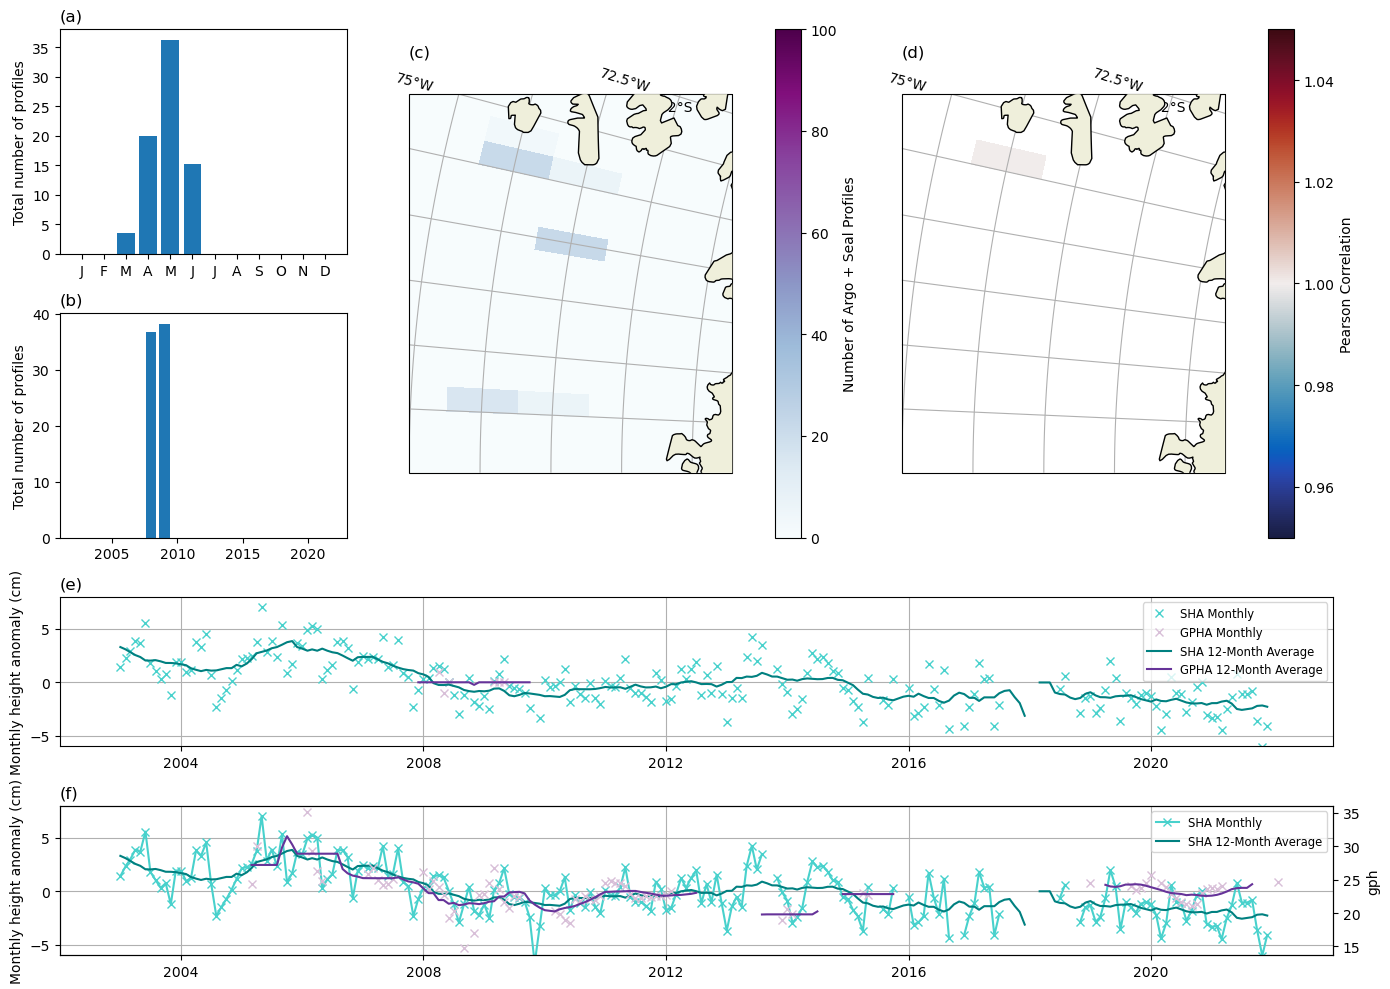

In [33]:
# gpha, sla, gridded
fig = plt.figure(figsize=(14,10))
axs=[]

gs = fig.add_gridspec(4,3,height_ratios=[1.5,1.5,1,1],width_ratios=[1,1.5,1.5])

# sha, gpha and sic climatology
axs.append(fig.add_subplot(gs[0, 0]))
axs.append(fig.add_subplot(gs[1, 0]))

axs[0].bar(monthly_sum.month,monthly_sum.sum(['latitude','longitude']))
axs[0].set_xticks(np.arange(1,13))
axs[0].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
#axs[0].ax.set_xlim([0.5,12.5])
axs[0].set_ylabel('Total number of profiles')
axs[0].set_title('(a)',loc='left')


axs[1].bar(yearly_sum.year,yearly_sum.sum(['latitude','longitude']))
axs[1].set_xlim([2001,2023])
axs[1].set_ylabel('Total number of profiles')
axs[1].set_title('(b)',loc='left')

axs[0].set_title('(a)',loc='left')
axs[1].set_title('(b)',loc='left')

# density and correlation
axs.append(fig.add_subplot(gs[0:2, 1],projection=ccrs.SouthPolarStereo()))
axs.append(fig.add_subplot(gs[0:2, 2],projection=ccrs.SouthPolarStereo()))

pfns.sp(axs[2],sha_gph_sla.profile_cnt.sum(('time')),vmin=0,vmax=100,cbar="Number of Argo + Seal Profiles",cmap='BuPu',cbar_orientation='vertical',extent=data_extent)
axs[2].set_title('(c)',loc='left')

pfns.sp(axs[3],xr.corr(sha_gph_sla.sha,sha_gph_sla.profile_gpha,dim='time'),cmap=cmocean.cm.balance,cbar='Pearson Correlation',cbar_orientation='vertical',extent=data_extent)
axs[3].set_title('(d)',loc='left')

axs.append(fig.add_subplot(gs[2, 0:4]))

timeseries_compare(sha_gph_sla,annual=False,fig=fig,ax=axs[4])
axs[4].set_title('(e)',loc='left')
axs[4].set_ylim([-6,8])
axs[4].set_xlim([pd.Timestamp(2002,1,1),pd.Timestamp(2023,1,1)])

axs.append(fig.add_subplot(gs[3,0:4]))

timeseries_compare_nongrid(sha_gph_sla,fig=fig,ax=axs[5])
axs[5].set_title('(f)',loc='left')
axs[5].set_ylim([-6,8])
axs[5].set_xlim([pd.Timestamp(2002,1,1),pd.Timestamp(2023,1,1)])


plt.tight_layout()

